In [12]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import seaborn as sns



In [3]:
#Data ingestion
df = pd.read_csv('./dataset/employee_attrition_performance.csv')
df.head()

,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,EMP00001,42,Female,Master,Finance,Role_22,107433,2,0,3.4,...,Yes,11,3,21,0,1,0,1,4,No
1,EMP00002,35,Male,Master,HR,Role_8,77660,4,0,3.4,...,Yes,30,4,29,1,2,0,3,3,No
2,EMP00003,40,Male,PhD,Legal,Role_1,114377,3,0,4.1,...,No,10,2,72,0,3,2,4,4,Yes
3,EMP00004,35,Male,High School,R&D,Role_15,79284,2,1,2.9,...,No,9,6,24,0,0,0,3,3,No
4,EMP00005,47,Male,Bachelor,Finance,Role_11,95933,1,1,3.3,...,No,10,2,52,0,0,3,2,3,No


In [4]:
# Check number of rows and columns

print("Dataset Shape :", df.shape)

# Display column names

print(df.columns)

# Display data types

df.info()

# Basic statistical summary

df.describe()

Dataset Shape : (10000, 22)
Index(['employee_id', 'age', 'gender', 'education', 'department', 'job_role',
       'monthly_salary', 'years_at_company', 'years_in_current_role',
       'performance_score', 'job_satisfaction', 'work_life_balance',
       'overtime', 'distance_from_home_km', 'num_projects_last_year',
       'training_hours_last_year', 'num_promotions',
       'last_promotion_years_ago', 'stock_option_level',
       'relationship_satisfaction', 'environment_satisfaction', 'attrition'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                10000 non-null  str    
 1   age                        10000 non-null  int64  
 2   gender                     10000 non-null  str    
 3   education                  10000 non-null  str    
 4   department                 10000 non-nul

,age,monthly_salary,years_at_company,years_in_current_role,performance_score,job_satisfaction,work_life_balance,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.848500,85422.334500,3.815100,1.301900,3.435560,3.168380,2.948500,10.618100,4.024900,39.795300,0.395200,0.921400,1.006800,2.902200,2.898700
std,9.501872,18519.436876,4.131588,1.764275,0.525579,0.961153,0.804806,10.212349,1.949477,19.604056,0.650276,1.362721,1.003322,0.940916,0.933555
min,22.000000,38957.000000,0.000000,0.000000,1.400000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,31.000000,72177.750000,1.000000,0.000000,3.100000,2.500000,3.000000,3.000000,3.000000,26.000000,0.000000,0.000000,0.000000,2.000000,2.000000
50%,37.000000,84043.500000,3.000000,1.000000,3.400000,3.200000,3.000000,7.000000,4.000000,40.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,45.000000,97020.000000,6.000000,2.000000,3.800000,3.900000,3.000000,14.000000,5.000000,53.000000,1.000000,1.000000,2.000000,4.000000,4.000000
max,65.000000,163489.000000,33.000000,15.000000,5.000000,5.000000,4.000000,107.000000,10.000000,119.000000,4.000000,14.000000,3.000000,4.000000,4.000000


In [5]:
# Check missing values

print(df.isnull().sum())

# Remove rows containing missing values

df = df.dropna()

# Remove duplicate records

df = df.drop_duplicates()

# Verify dataset after cleaning

print("New Shape :", df.shape)

employee_id                  0
age                          0
gender                       0
education                    0
department                   0
job_role                     0
monthly_salary               0
years_at_company             0
years_in_current_role        0
performance_score            0
job_satisfaction             0
work_life_balance            0
overtime                     0
distance_from_home_km        0
num_projects_last_year       0
training_hours_last_year     0
num_promotions               0
last_promotion_years_ago     0
stock_option_level           0
relationship_satisfaction    0
environment_satisfaction     0
attrition                    0
dtype: int64
New Shape : (10000, 22)


In [15]:
# ENCODE CATEGORICAL VARIABLES

label_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\Soham Deshmukh\AppData\Local\Temp\ipykernel_29356\428564524.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  label_cols = df.select_dtypes(include="object").columns


,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,0,42,0,2,1,14,107433,2,0,3.4,...,1,11,3,21,0,1,0,1,4,0
1,1,35,1,2,2,47,77660,4,0,3.4,...,1,30,4,29,1,2,0,3,3,0
2,2,40,1,3,3,0,114377,3,0,4.1,...,0,10,2,72,0,3,2,4,4,1
3,3,35,1,1,6,6,79284,2,1,2.9,...,0,9,6,24,0,0,0,3,3,0
4,4,47,1,0,1,2,95933,1,1,3.3,...,0,10,2,52,0,0,3,2,3,0


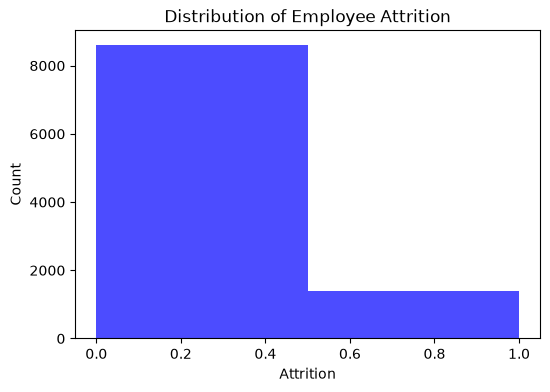

In [16]:
# Plot distribution of employee attrition
plt.figure(figsize=(6, 4))
plt.hist(df['attrition'], bins=2, color='blue', alpha=0.7)
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()



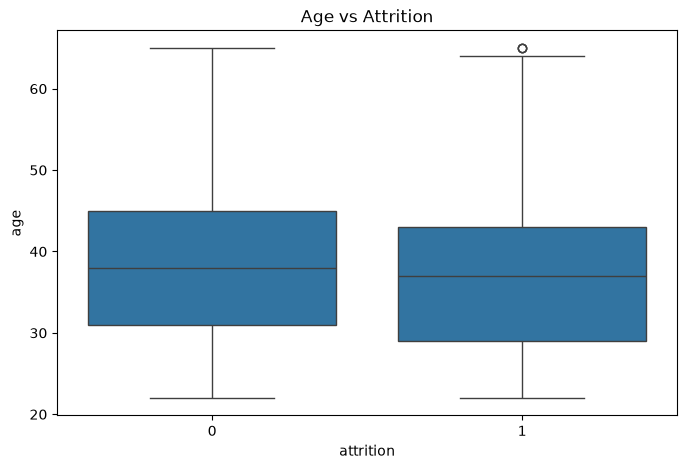

In [17]:
# AGE VS ATTRITION
plt.figure(figsize=(8,5))
sns.boxplot(x="attrition", y="age", data=df)
plt.title("Age vs Attrition")
plt.show()

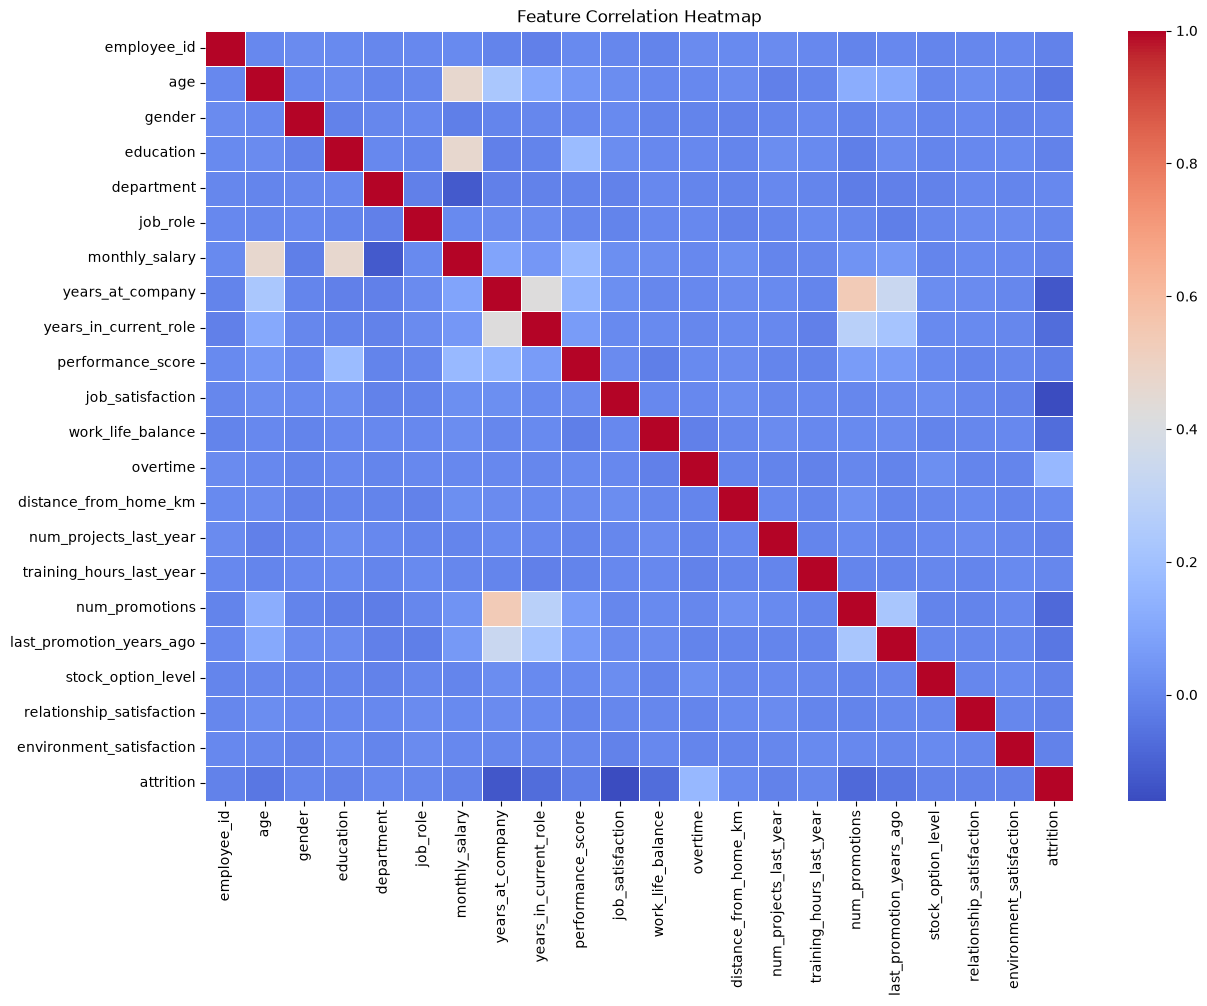

In [18]:
# CORRELATION HEATMAP

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

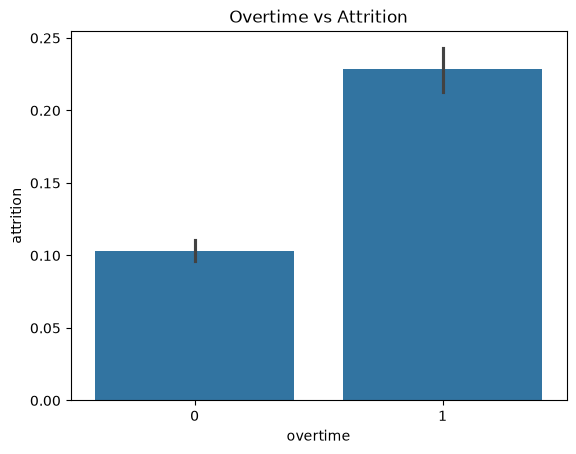

In [19]:
#Overrtime vs Attrition
sns.barplot(x="overtime", y="attrition", data=df)
plt.title("Overtime vs Attrition")
plt.show()

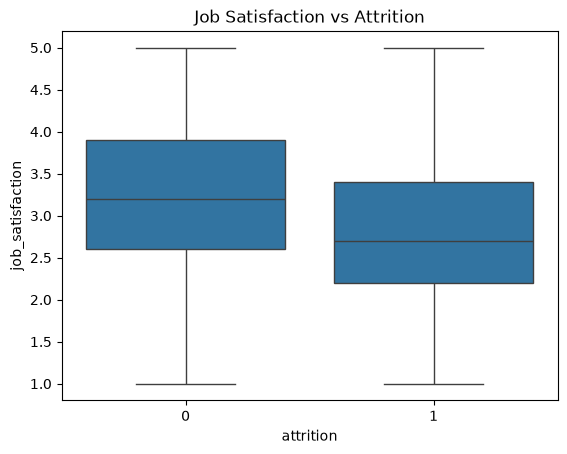

In [20]:
# Job satisfaction vs Attrition
sns.boxplot(x="attrition", y="job_satisfaction", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

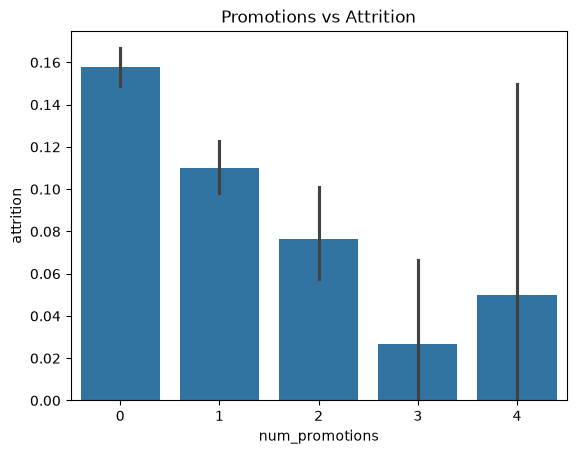

In [21]:
#Promotions vs Attrition
sns.barplot(x="num_promotions", y="attrition", data=df)
plt.title("Promotions vs Attrition")
plt.show()

In [23]:
# Split data into training and testing
X = df.drop("attrition", axis=1)
y = df["attrition"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [24]:
# Scale input features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
# Create ANN model

model = Sequential()

# Input layer

model.add(Dense(64,
                activation="relu",
                input_shape=(X_train.shape[1],)))

# Hidden layer

model.add(Dense(32,
                activation="relu"))

# Hidden layer

model.add(Dense(16,
                activation="relu"))

# Output layer

model.add(Dense(1,
                activation="sigmoid"))

c:\Users\Soham Deshmukh\Desktop\B.Tech\ADS\ADS-PEIT412B\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Configure the ANN

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [27]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1267 - mae: 0.2591 - val_loss: 0.1154 - val_mae: 0.2332
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1111 - mae: 0.2214 - val_loss: 0.1154 - val_mae: 0.2157
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1093 - mae: 0.2182 - val_loss: 0.1151 - val_mae: 0.2283
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1078 - mae: 0.2148 - val_loss: 0.1156 - val_mae: 0.2197
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1065 - mae: 0.2144 - val_loss: 0.1168 - val_mae: 0.2009
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1054 - mae: 0.2095 - val_loss: 0.1173 - val_mae: 0.2315
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1038 - mae: 0.2089 - val_loss: 0.1162 - val_mae: 0.2165
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1019 - mae: 0.2053 - val_loss: 0.1184 - val_mae: 0.2164
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [28]:
# Evaluate on testing data

loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)
print("Test MAE :", mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1792 - mae: 0.2173  
Test Loss : 0.17920078337192535
Test MAE : 0.21726909279823303


In [29]:
# Predict house prices

predictions = model.predict(X_test)

predictions = predictions.flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [30]:
# Calculate evaluation metrics

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)
print("Root Mean Square Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 0.21726910769939423
Root Mean Square Error : 0.4233211350404387
R2 Score : -0.49734532833099365


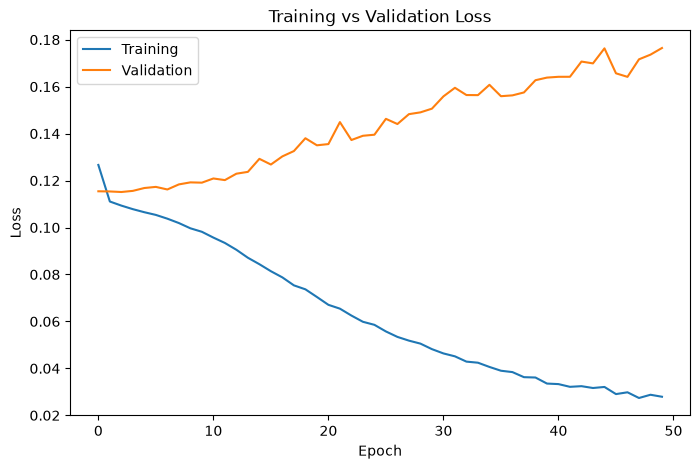

In [31]:
# Plot training loss

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend(["Training","Validation"])

plt.show()

In [33]:
#Evaluate classification metrics
print(classification_report(y_test, predictions.round()))


              precision    recall  f1-score   support

           0       0.88      0.87      0.88      1722
           1       0.27      0.29      0.28       278

    accuracy                           0.79      2000
   macro avg       0.58      0.58      0.58      2000
weighted avg       0.80      0.79      0.79      2000



The dataset was successfully loaded and cleaned.

Basic exploratory data analysis was performed to understand the data.

The features were scaled before training the neural network.

An Artificial Neural Network with three hidden layers was developed using TensorFlow/Keras.

The model was trained using the Adam optimizer and Mean Squared Error loss function.

Finally, the model was evaluated using MAE, RMSE and R² Score for house price prediction.
(Binary Classification)